# 2D Structure Function / LLC4320 Data

This example will guide you through each step necessary to compute scalar-based structure functions from a 2D dycoms dataset

$\textbf{General procedure}:$


1 -  Load LLC4320 Subset dataset, the dataset can be accessed upon request

2 -  Format dataset to match pyturbo_sf inputs

3 -  Calculate second-order Isotropic structure function as a function of separation distances

4 -  Plot the Isotropic SF with errors and number of bootstraps and slope

5 - Compute conditional (Sea-Ice concentration) Second Order SF

6 - Plot Conditional  SF


$\textbf{Motivation:}$

This example demonstrates the computation of second order structure functions from 2D MITGCM Arctic data. It also shows how to compute conditional Structure function based on some variable, here Sea Ice Concentration

$\textbf{Note:}$

This is Part of Ashfaq Ahmed's PhD work. Please feel free to reach out to him through email for more questions (ashfaq_ahmed@brown.edu)



In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.pyplot import cm
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load Dataset

In [2]:
idt = 330
dsg = xr.open_dataset('/home/aayouche/Downloads/FRAM_grid.nc')
dsu = xr.open_dataset('/home/aayouche/Downloads/FRAM_u.nc').isel(time=idt)
dsv = xr.open_dataset('/home/aayouche/Downloads/FRAM_v.nc').isel(time=idt)
dsm = xr.open_dataset('/home/aayouche/Downloads/FRAM_sic.nc').isel(time=idt)
u = dsu.U.rename({'j':'y','i':'x'})
v = dsv.V.rename({'j':'y','i':'x'})
sic = dsm.SIarea.rename({'j':'y','i':'x'})
lon = dsg.XC
lat = dsg.YC


# Create the projection
proj = pyproj.Proj("EPSG:3995")

x, y = proj(lon.values, lat.values)


y_dim, x_dim = x.shape

X = xr.DataArray(
    x,
    dims=['y', 'x'],
    coords={
        'y': np.arange(y_dim),
        'x': np.arange(x_dim)
    }
)

Y = xr.DataArray(
    y,
    dims=['y', 'x'],
    coords={
        'y': np.arange(y_dim),
        'x': np.arange(x_dim)
    }
)



# Make a quick plot

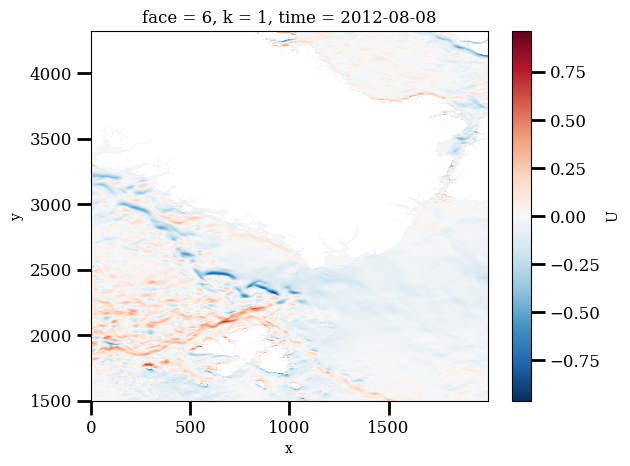

In [3]:
u.plot()

# Prepare Dataset for Pyturbo

In [4]:
ds = xr.Dataset(
    data_vars={
        'u': u,
        'v': v,
        'sic': sic,
    },
    coords={
        'x': X,
        'y': Y,
    }
)

In [5]:
ds


<xarray.Dataset> Size: 158MB
Dimensions:  (y: 2820, x: 2000)
Coordinates:
    y        (y, x) float64 45MB -3.539e+05 -3.54e+05 ... 1.968e+06 1.968e+06
    x        (y, x) float64 45MB 1.999e+06 1.999e+06 ... -9.46e+04 -9.55e+04
    face     int64 8B 6
    k        int64 8B 1
    time     datetime64[ns] 8B 2012-08-08
Data variables:
    u        (y, x) float32 23MB ...
    v        (y, x) float32 23MB ...
    sic      (y, x) float32 23MB ...

# Define Keywords for Isotropic/Conditional Second Order SF

In [6]:
nbins = 11
# Fewer bins = more shifts per bin
bin_r = np.logspace(np.log10(1e3), np.log10(1e6), nbins+1)  # Start at 5 km
bins = {'r': bin_r}

sf_kwargs_is = dict(
    ds=ds,
    variables_names=['u','v'],
    bootsize={'y': 88//4, 'x': 62//4},
    bins=bins,
    fun='default_vel',
    order=2,
    initial_nbootstrap=5000,
    max_nbootstrap=5000,
    step_nbootstrap=0,
    convergence_eps=0.001,
    confidence_interval=0.95,
    n_jobs=-1,
    backend='loky',
    seed=42
)

sf_kwargs_cond = dict(
    ds=ds,
    variables_names=['u','v'],
    bootsize={'y': 88//4, 'x': 62//4},
    bins=bins,
    fun='default_vel',
    order=2,
    initial_nbootstrap=5000,
    max_nbootstrap=5000,
    step_nbootstrap=0,
    convergence_eps=0.001,
    confidence_interval=0.95,
    conditioning_var='sic',
    conditioning_bins=np.linspace(-0.01,1.01,11),#[0,0.15] or [0.15,0.8] or [0.8,1.0]
    n_jobs=-1,
    backend='loky',
    seed=42
)

# Compute Second Order SF & Conditional

In [7]:
%%time
iso_sf = psf.get_isotropic_sf_2d(**sf_kwargs_is)
gc.collect()
iso_cond = psf.get_isotropic_sf_2d(**sf_kwargs_cond)


Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 22, 'x': 15}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16, 32, 64, 128]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: default_vel
Variables: ['u', 'v'], Order: 2
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 625 bootstraps
Processing spacing 2 with 625 bootstraps
Processing spacing 4 with 625 bootstraps
Processing spacing 8 with 625 bootstraps
Processing spacing 16 with 625 bootstraps
Processing spacing 32 with 625 bootstraps
Processing spacing 64 with 625 bootstraps
Processing spacing 128 with 625 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 70309354
Bins with points: 11/11
Marked 6 bins as converged (converged_eps)
Marked 5 bins as converged (max_bootstraps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data (>10 poin

/home/aayouche/Documents/postdoc/coding/pyturbo_sf/src/pyturbo_sf/two_dimensional.py:271: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_combined = xr.concat(datasets, dim='cond_bin')


In [8]:
gc.collect()

0

# Plot Second Order SF 

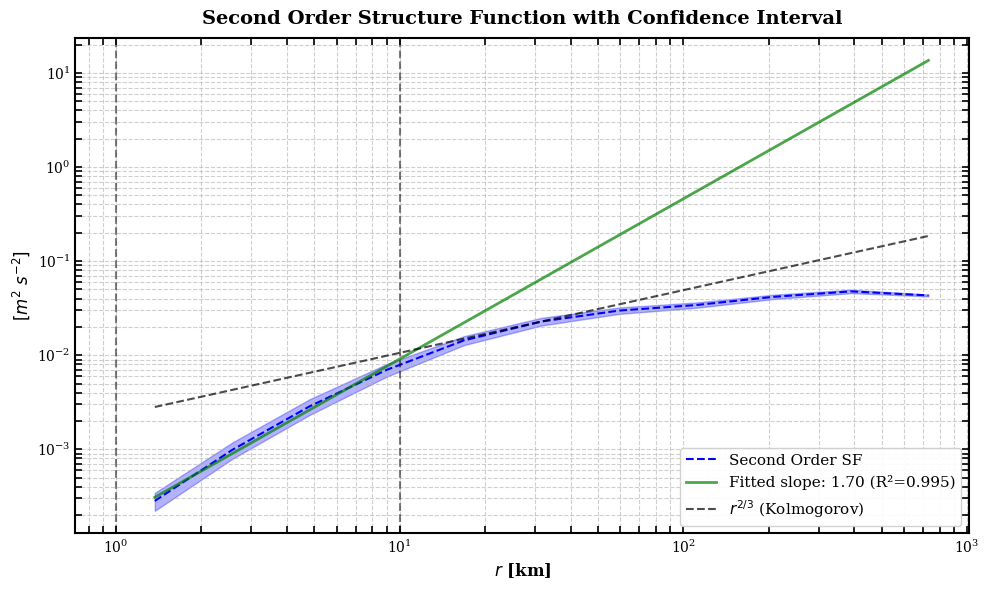

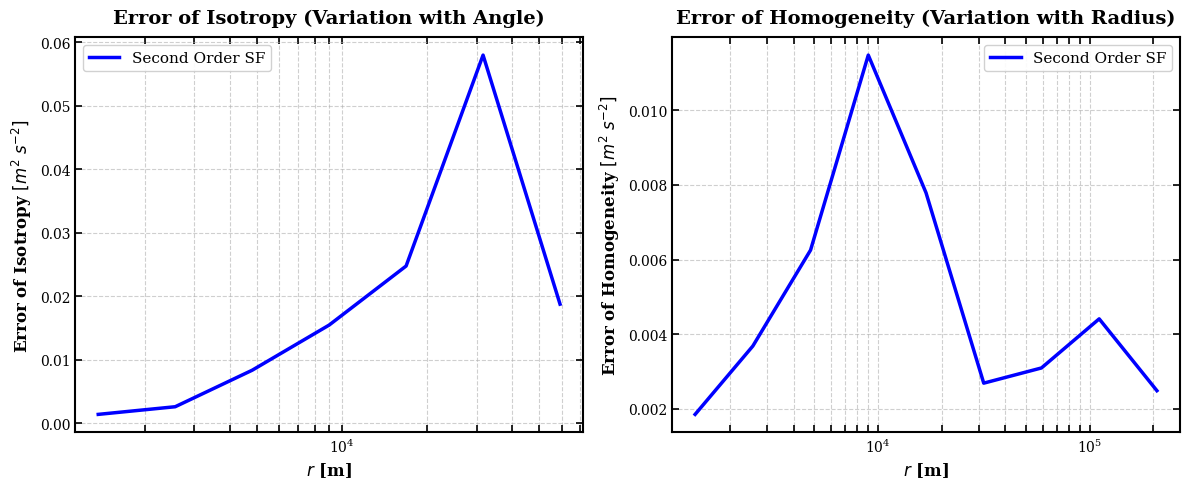

In [9]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
# Add longitudinal structure function with error bars
plt.loglog(iso_sf.r/1e3, iso_sf.sf, 'b--', linewidth=1.5, label='Second Order SF')
plt.fill_between(iso_sf.r/1e3,iso_sf.ci_lower,iso_sf.ci_upper,color='b',alpha=0.3)
plt.axvline(1,linestyle='--',alpha=0.5,color='k')
plt.axvline(10,linestyle='--',alpha=0.5,color='k')

cond = np.max(np.where(iso_sf.r<=10.0e3)) # Compute the actual slope from the data (excluding first and last points)

log_r = np.log10(iso_sf.r[:cond+1])
log_sf = np.log10(iso_sf.sf[:cond+1])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_r, log_sf)

# Plot the fitted line
r_fit = iso_sf.r/1e3
fitted_line = 10**intercept * (r_fit*1e3)**slope
plt.loglog(r_fit, fitted_line, 'g-', alpha=0.7, linewidth=2, 
           label=f'Fitted slope: {slope:.2f} (R²={r_value**2:.3f})')

# Add Kolmogorov 2/3 slope reference line
r_ref = iso_sf.r/1e3  # in km
mid_idx = len(r_ref)//2
amplitude = iso_sf.sf[mid_idx] / (r_ref[mid_idx]**(2/3))
kolmogorov_line = amplitude * r_ref**(2/3)
plt.loglog(r_ref, kolmogorov_line, 'k--', alpha=0.7, label=r'$r^{2/3}$ (Kolmogorov)')


# Formatting
plt.xlabel(r'$r$ [km]', fontsize=12, fontweight='bold')
plt.ylabel(r'$[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('Second Order Structure Function with Confidence Interval', 
         fontsize=14, fontweight='bold', pad=10)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.yscale('log')
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf.r, iso_sf.error_isotropy, 'b-', linewidth=2.5,label='Second Order SF')

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf.r_subset, iso_sf.error_homogeneity, 'b-', linewidth=2.5,label='Second Order SF')
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

In [10]:
iso_cond

<xarray.Dataset> Size: 44kB
Dimensions:            (theta: 36, r: 11, cond_bin: 10, r_subset: 9,
                        r_edge: 12, theta_edge: 37)
Coordinates:
  * theta              (theta) float64 288B -3.054 -2.88 -2.705 ... 2.88 3.054
  * r                  (r) float64 88B 1.369e+03 2.565e+03 ... 7.305e+05
  * cond_bin           (cond_bin) float64 80B 0.041 0.143 0.245 ... 0.857 0.959
  * r_subset           (r_subset) float64 72B 1.369e+03 2.565e+03 ... 2.081e+05
Dimensions without coordinates: r_edge, theta_edge
Data variables: (12/13)
    sf_polar           (theta, r, cond_bin) float64 32kB 0.000438 ... 0.01002
    sf                 (r, cond_bin) float64 880B 0.0004967 ... 0.01651
    error_isotropy     (r, cond_bin) float64 880B 0.001452 nan nan ... nan nan
    std_error          (r, cond_bin) float64 880B 5.593e-05 ... 0.0003796
    ci_upper           (r, cond_bin) float64 880B 0.0006063 0.001525 ... 0.01725
    ci_lower           (r, cond_bin) float64 880B 0.000387 0.0001191 ... 0.01577
    ...                 ...
    n_bootstrap        (r, cond_bin) int64 880B 5000 5000 5000 ... 5000 5000
    bin_density        (r, cond_bin) float32 440B 1.0 1.0 ... 7.936e-06
    point_counts       (r, cond_bin) int64 880B 287662 7030 ... 506873 121564
    converged          (r, cond_bin) bool 110B True True True ... True True True
    r_bins             (cond_bin, r_edge) float64 960B 1e+03 1.874e+03 ... 1e+06
    theta_bins         (cond_bin, theta_edge) float64 3kB -3.142 ... 3.142
Attributes: (12/15)
    order:                      2
    function_type:              default_vel
    window_size_theta:          12
    window_size_r:              3
    convergence_eps:            0.001
    max_nbootstrap:             5000
    ...                         ...
    confidence_level:           0.95
    bootstrappable_dimensions:  y,x
    backend:                    loky
    conditioning_variable:      sic
    conditioning_bin_edges:     [np.float64(-0.01), np.float64(0.092000000000...
    conditioning_bin_idx:       0

# Plot Second Order SF conditional (Sea-Ice)

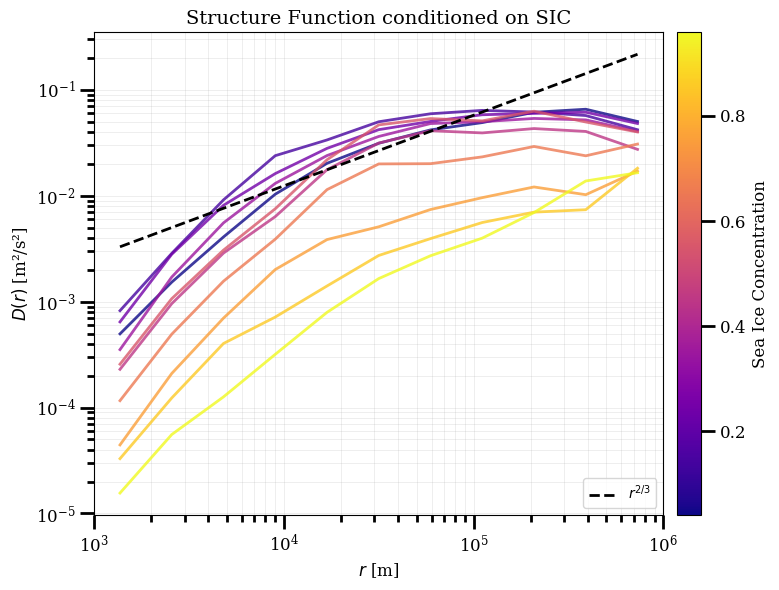

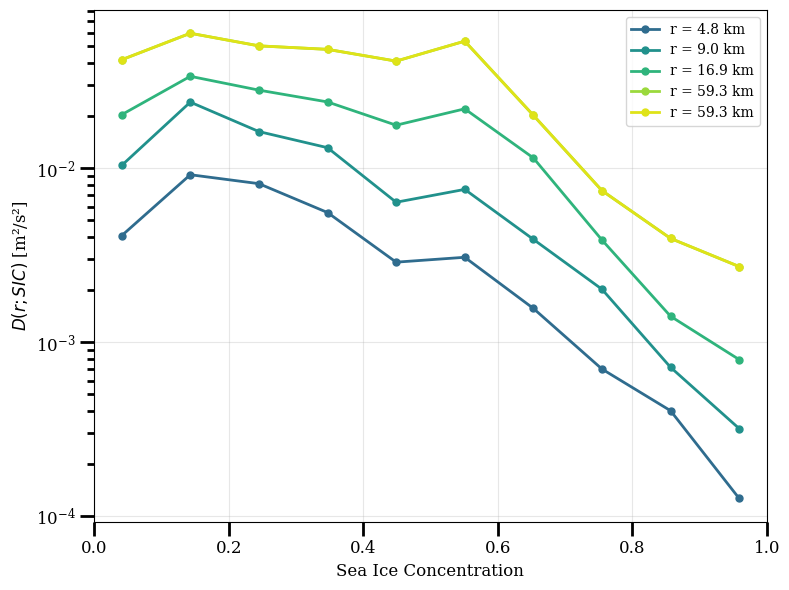

In [11]:
# Get the data
r = iso_cond.r.values  # radial bins
cond_bins = iso_cond.cond_bin.values  # bin centers (SIC values)
sf_cond_data = iso_cond.sf.values  # shape: (n_r, n_cond_bin)

# ============================================================
# Plot 1: D(r) vs r - colored band style like your figure
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Colormap - yellow to blue like your figure
cmap = plt.cm.plasma  # or try 'viridis', 'coolwarm', 'jet'
norm = mcolors.Normalize(vmin=cond_bins.min(), vmax=cond_bins.max())

# Plot each conditioning bin as a line
for i, sic_center in enumerate(cond_bins):
    color = cmap(norm(sic_center))
    ax.loglog(r, sf_cond_data[:, i], '-', color=color, linewidth=2, alpha=0.8)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Sea Ice Concentration', fontsize=12)

# Reference slope
r_ref = np.array([r.min(), r.max()])
# Adjust prefactor to fit your data
sf_ref = sf_cond_data[len(r)//2, :].mean()  # reference value
r_mid = r[len(r)//2]
prefactor = sf_ref / (r_mid**(2/3))
ax.loglog(r_ref, prefactor * r_ref**(2/3), 'k--', linewidth=2, label=r'$r^{2/3}$')

ax.set_xlabel(r'$r$ [m]', fontsize=12)
ax.set_ylabel(r'$D(r)$ [m²/s²]', fontsize=12)
ax.set_title('Structure Function conditioned on SIC', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: D(SIC) at fixed r values  
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Select specific r values
r_values_km = [5, 10, 20, 50, 80]  # km
cmap_r = plt.cm.viridis
norm_r = mcolors.LogNorm(vmin=1, vmax=100)

for r_km in r_values_km:
    r_target = r_km * 1e3  # convert to m
    idx = np.argmin(np.abs(r - r_target))
    r_actual = r[idx]
    color = cmap_r(norm_r(r_km))
    ax.plot(cond_bins, sf_cond_data[idx,:], '-o', color=color,
            label=f'r = {r_actual/1e3:.1f} km', markersize=5, linewidth=2)

ax.set_xlabel('Sea Ice Concentration', fontsize=12)
ax.set_ylabel(r'$D(r; SIC)$ [m²/s²]', fontsize=12)
ax.set_yscale('log')
ax.set_xlim([0, 1])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Total Conditionned vs Total SF

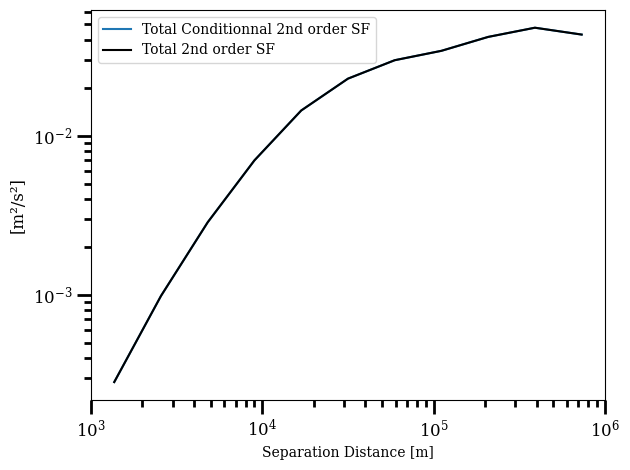

In [12]:
plt.loglog(r,((iso_cond.sf*iso_cond.point_counts).sum('cond_bin'))/iso_cond.point_counts.sum('cond_bin'),label='Total Conditionnal 2nd order SF')
plt.loglog(r,iso_sf.sf,'k',label='Total 2nd order SF')
plt.xlabel('Separation Distance [m]')
plt.ylabel('[m²/s²]', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()